In a previous notebook I replicated Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am not going to try to adapt it to work for ALMA Band 7

## Load Intro Things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND7_nterms2/load_band7_nterms2_data.py"

band = Band 7 nterms2
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


# Image

In [4]:
StokesI_stretched_mJy, StokesI_unstretched_cbar_ticks = normalize_stokesI_for_cmap(StokesI_mJy,
                                                                                   custom_min = 0.00002 * 1000,
                                                                                   custom_max = 0.003 * 1000)

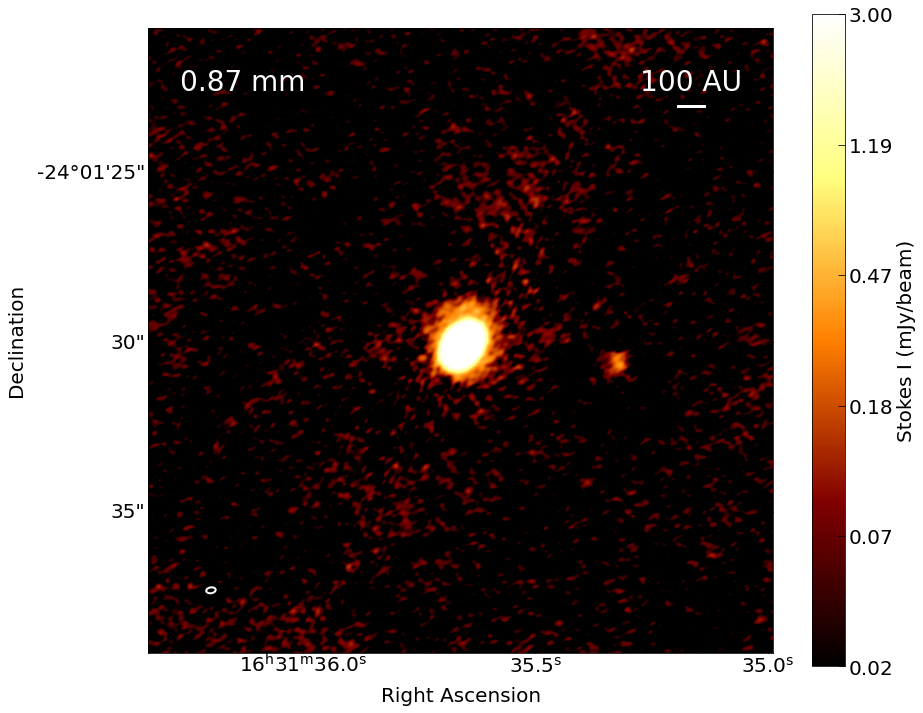

In [5]:
fig, ax = create_stokes_i_base_plot("Band 7 nterms2", StokesI_wcs, StokesI_stretched_mJy, "afmhot", 
                              normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                              0, nx, 0, ny, 
                              reference_length_pix, reference_length_AU,
                              BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                              max_length_pix, reference_fraction, 
                              label = 'wavelength', fontcolor = 'white')

plt.savefig(writeup_image_folder_path + '/GalaxyContamination/'+ "StokesI_BAND7.pdf", 
            dpi=300, 
            bbox_inches='tight')   

# Primary Beam

In [6]:
# Load in the pb
pb_path = constants.band7_nterms2_data_folder_path + "IRS63_BAND7_pb.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

In [7]:
# Code from the function 
    
ny, nx = pb_map.shape
    
flat_index = np.nanargmax(pb_map)   # ignores NaNs, finds max
y_cen, x_cen = np.unravel_index(flat_index, pb_map.shape)

dr_arcsec = 0.25 

dr_pix = arcsec_to_pixels(header, dr_arcsec)

r_pix = np.arange(0, nx - x_cen, dr_pix)
r_arcsec = pixels_to_arcsec(header, r_pix)

x_pos = x_cen + r_pix.astype(int)

pb_val_arr = pb_map[y_cen, x_pos].astype(np.float32).newbyteorder('=')

y_arr = np.full(len(pb_val_arr), y_cen)

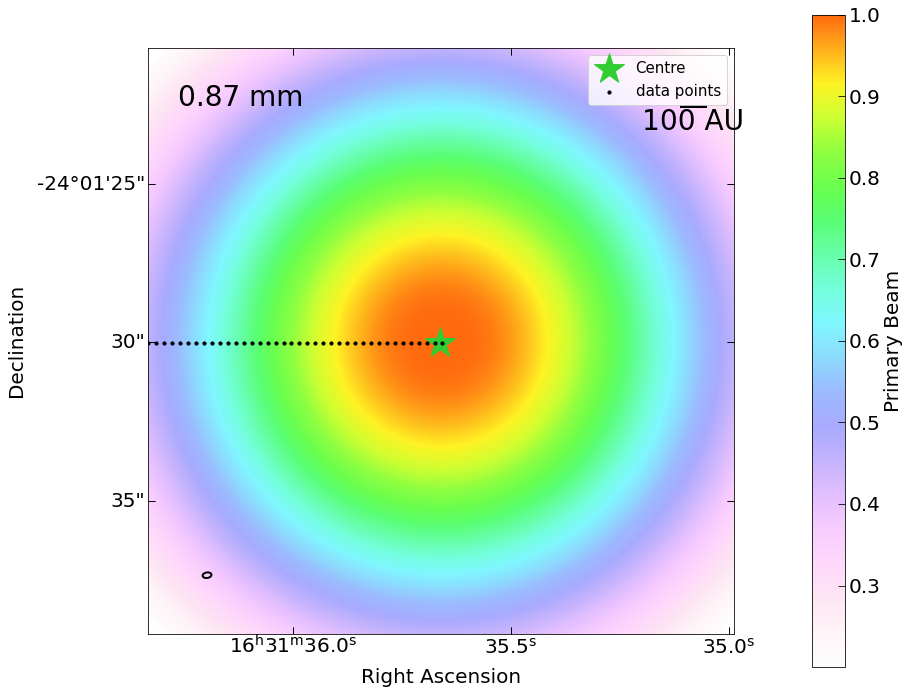

In [8]:
fig, ax = create_base_plot('Band 7 nterms2', 
                           StokesI_wcs, 
                           pb_map, 'Primary Beam', 
                           soft_colormap_no_red, 
                           0, nx, 0, ny, 
                           reference_length_pix, reference_length_AU,
                           BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                           max_length_pix, reference_fraction,
                           label ='wavelength')

ax.scatter(x_cen, y_cen, label = 'Centre', s = 1000, color = 'limegreen', marker = '*')

ax.scatter(r_pix, y_arr, label = 'data points', s = 10, color = 'black', marker = 'o')


ax.legend(fontsize = legend_text_fs)

In [9]:
from scipy.optimize import curve_fit
import numpy as np

def pb_model(r, A, sigma):
    return A * np.exp(-0.5 * (r / sigma)**2)

# Give reasonable initial guesses!
p0 = [1.0, 5.0]   # A ~ 1, sigma ~ a few arcsec/pixels

popt, pcov = curve_fit(pb_model, r_arcsec, pb_val_arr, p0=p0)
A_fit, sigma_fit = popt

pd_fit = pb_model(r_arcsec, A_fit, sigma_fit)

r_ext = np.linspace(0, 15, 300)
pd_ext = pb_model(r_ext, A_fit, sigma_fit)


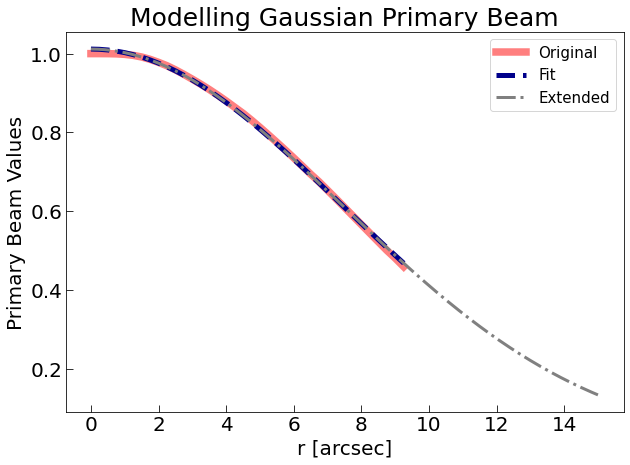

In [10]:
# Plot the data
fig, ax = plt.subplots(figsize=(10,7))

ax.plot(r_arcsec, pb_val_arr, lw = 7.5, color = 'red',       alpha = 0.5, ls = '-',  label = 'Original')
ax.plot(r_arcsec, pd_fit,     lw = 5, color = 'darkblue',  alpha = 1.0, ls = '--', label = 'Fit')
ax.plot(r_ext,    pd_ext,     lw = 3.0, color = 'grey',      alpha = 1.0, ls = '-.', label = 'Extended')


# Set axis labels and title
ax.set_xlabel('r [arcsec]', fontsize = axis_label_fs)
ax.set_ylabel(r'Primary Beam Values', fontsize = axis_label_fs)
ax.set_title(rf'Modelling Gaussian Primary Beam', fontsize = title_fs)

# Add a legend
ax.legend(fontsize = 15)

# Format the axes how I want the,
plt.tick_params(axis="x", which="major", direction="in", bottom=True, length=7, labelsize = axis_num_fs)
plt.tick_params(axis="y", which="major", direction="in", bottom=True, length=7, labelsize = axis_num_fs)

plt.show()
# ---------------------------------------------------------------------------------------------------

## Band 7

In [11]:
# sn_array = [5, 10, 20]

sn_array = [5, 9, 20]

y_cen, x_cen, df, dfs = run_galaxy_contamination("Band 7 nterms2", sn_array, spacing = 'linspace')

The Schecter function form that is being used is: dN_dS = 1.15e3 * (N0 / S0) * (S / S0)**alpha * np.exp(-S/S0)
The Schecter best-fit parameters being used are: N0 = 2.2 mJy^-1 deg^-2, S0 = 3.9 mJy, and alpha = -1.7
These values are from Chen et al. (2022)
 
The dr value is: 0.25 arcsec
 
The centre position is: (y, x) = (509, 510), and at this position pb = 1.0
 


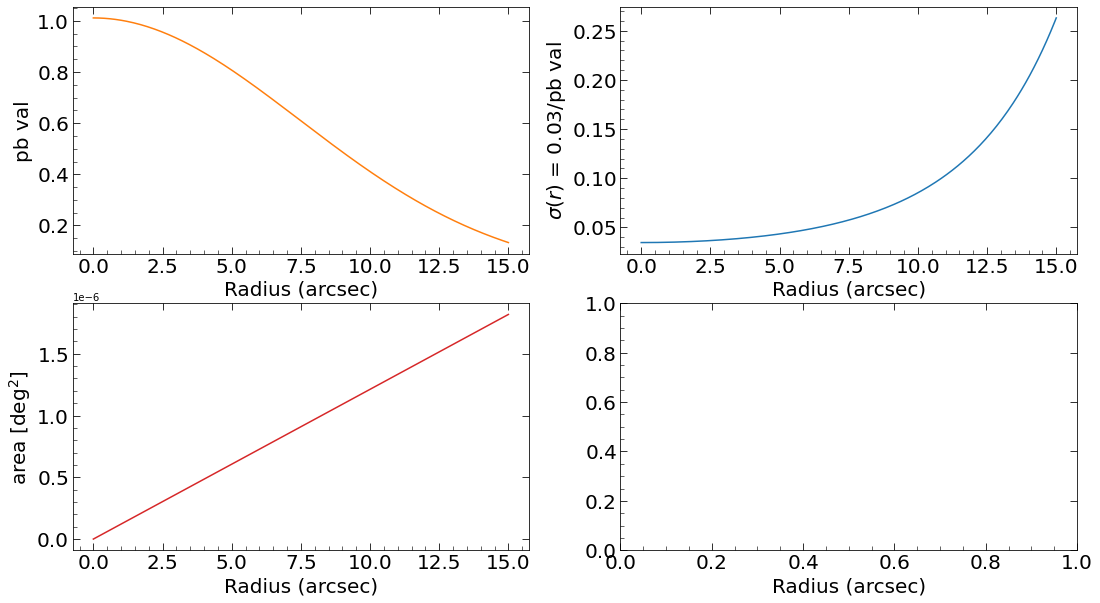

In [12]:
fig, ax = plot_galaxy_contamination_models(df)

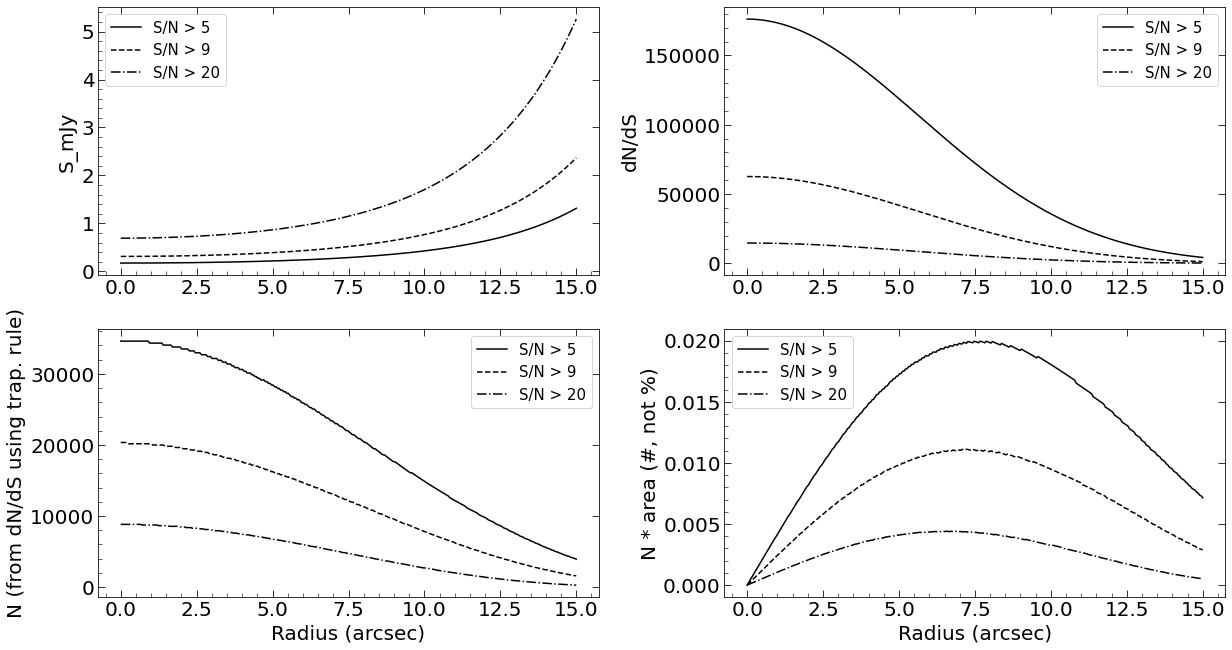

In [13]:
fig, ax = plot_probability_models(dfs, sn_array)

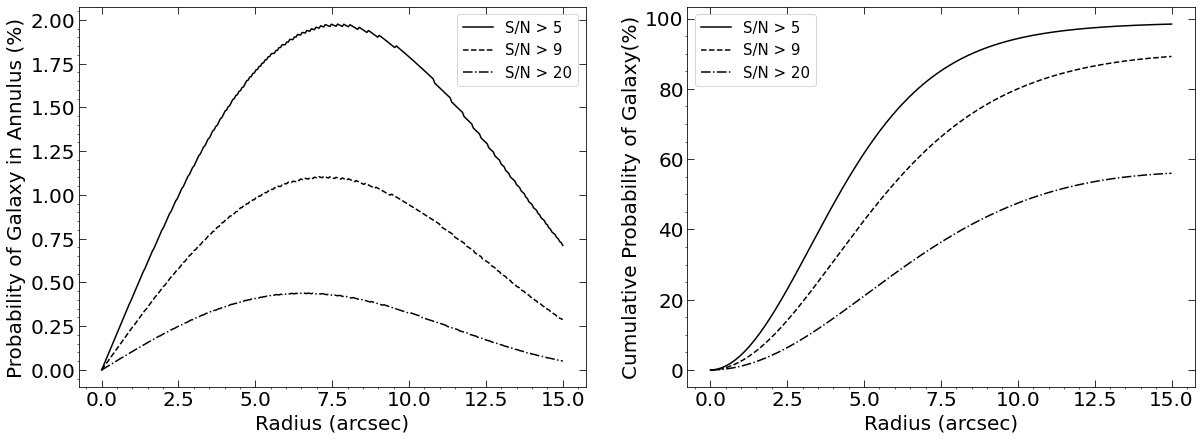

In [14]:
fig, ax = recreate_figs_11_12_sadavoy2019(dfs, sn_array)


plt.savefig(writeup_image_folder_path + '/GalaxyContamination/'+ "Probabilities_Band7.pdf", 
            dpi=300, 
            bbox_inches='tight')  

## Find probability

In [15]:
# Check it the function way:
GC_probability(x_cen, y_cen, df, dfs, StokesI_mJy, sn_array, "Band 7 nterms2", distance = "x", print_things = True)

The Stokes I peak on the source is: 0.4008985706605 mJy
At Band 7 the error in Stokes I is: 0.035175 mJy
The primary beam (pb) value at this peak Stokes I is 0.828187 
When we find S/N, the noise is StokesI_err/pb = 0.04247229188576976
S/N =  9.43906139416084
 
     Checkpoint: Stokes I inputted and mapped values match
     Checkpoint: The hypotenuse values match up
 
The distance to the source in x is  : 4.752 arcsec
The distance to the soruce in df is : 4.765886287625418 arcsec
 
If the source S/N > 5:
     The cumulative prob is: 58.49% at 4.77 arcsec
 
If the source S/N > 9:
     The cumulative prob is: 39.89% at 4.77 arcsec
 
If the source S/N > 20:
     The cumulative prob is: 19.55% at 4.77 arcsec
 


# Chen Plots

In [16]:
def schechter_chencode(s, a=0, S0=1, N0=1):
    return N0*3600/S0*(s/S0)**(a+1)*np.exp(-s/S0)

(0.1, 100000)

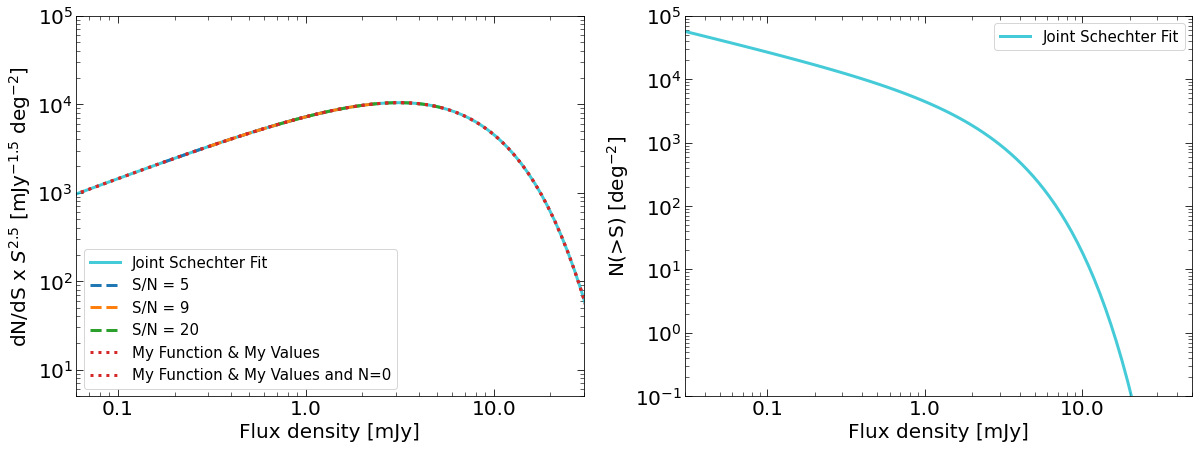

In [17]:
# make the figures
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

S_plotting = np.logspace(-2, 1.5, 100)

# Add Chen Fit lines
# # ------------------------------------------------------------------------------------
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # [alpha-1 + 1, S0, N0], N0 here in mJy/arcmin2
ax[0].plot(S_plotting, 
        S_plotting**2.5 *schechter_chencode(S_plotting, *B7_schechter_diffsols[:-1]), 
        color='tab:cyan', 
        linewidth=3, 
        alpha=0.8, 
        label='Joint Schechter Fit')
# # ------------------------------------------------------------------------------------
B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1+1, S0, N0]

ax[1].plot(S_plotting, 
        schechter_chencode(S_plotting, *B7_schechter_sols), 
        linewidth=3., 
        alpha=0.8, 
        color='tab:cyan', 
        label='Joint Schechter Fit')
# ------------------------------------------------------------------------------------



# Plot my data 
# ------------------------------------------------------------------------------------
colors = sns.color_palette('tab10', 5)
for i in range(3):
    
    ax[0].plot(dfs[i]['S_mJy'],
           dfs[i]['S_mJy']**2.5 * dfs[i]['dN_dS'],
           label = rf'S/N = {sn_array[i]}',
           lw = 3,
           color = colors[i],
           ls = '--')
# ------------------------------------------------------------------------------------


# Plot the data with their S values using my function
# ------------------------------------------------------------------------------------
ax[0].plot(S_plotting, 
        S_plotting**2.5 * galaxy_probability(S_plotting, 'Band 7 nterms2'), 
        color = colors[3], 
        lw = 3, 
        ls = ':',
        label='My Function & My Values')
# ------------------------------------------------------------------------------------
ax[0].plot(S_plotting, 
        S_plotting**2.5 * galaxy_probability(S_plotting, 'Band 7 nterms2', sf = 3600), 
        color = colors[3], 
        lw = 3, 
        ls = ':',
        label='My Function & My Values and N=0')
# ------------------------------------------------------------------------------------


# Set y-axis labels 
# ----------------------------------------------------------------------------------------------
ax[0].set_ylabel('dN/dS x $S^{2.5}$ [mJy$^{-1.5}$ deg$^{-2}$]', fontsize = axis_label_fs)
ax[1].set_ylabel('N(>S) [deg$^{-2}$]',  fontsize = axis_label_fs)
# ----------------------------------------------------------------------------------------------

# Add an x-label, proper ticks on axes and add a legend
# ----------------------------------------------------------------------------------------------
for i in range(2):

    # Add axis labels
    ax[i].set_xlabel(r'Flux density [mJy]', fontsize=axis_label_fs)

    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
    ax[i].tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

    ax[i].legend(fontsize = legend_text_fs)
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    
    ax[i].xaxis.set_major_formatter(ScalarFormatter())
    ax[i].ticklabel_format(axis="x", style="plain")
# ----------------------------------------------------------------------------------------------
    
# Set the bounds
# ------------------------------------------
# Bounds of left plot from the paper code
ax[0].set_xlim(0.06, 30)
ax[0].set_ylim(5., 1e5)
# ------------------------------------------
# Bounds of right plot from the paper code
ax[1].set_xlim(0.03, 50)
ax[1].set_ylim(0.1, 10**5)
# ------------------------------------------

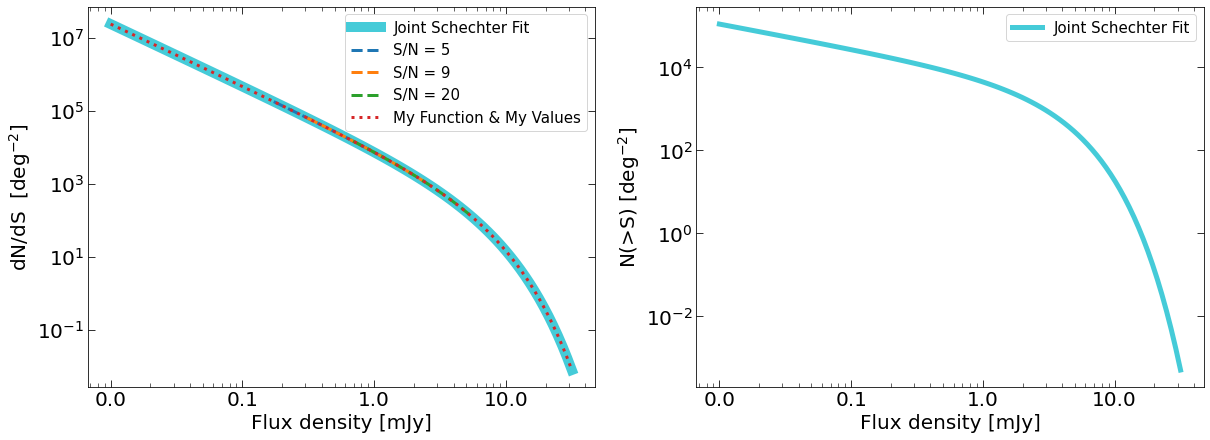

In [18]:
# make the figures
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

S_plotting = np.logspace(-2, 1.5, 100)

# Add Chen Fit lines
# # ------------------------------------------------------------------------------------
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # [alpha-1 + 1, S0, N0], N0 here in mJy/arcmin2
ax[0].plot(S_plotting, 
           schechter_chencode(S_plotting, *B7_schechter_diffsols[:-1]), 
           color='tab:cyan', 
           linewidth=10, 
           alpha=0.8, 
           label='Joint Schechter Fit')
# # ------------------------------------------------------------------------------------
B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1+1, S0, N0]

ax[1].plot(S_plotting, 
           schechter_chencode(S_plotting, *B7_schechter_sols), 
           linewidth=5., 
           alpha=0.8, 
           color='tab:cyan', 
           label='Joint Schechter Fit')
# ------------------------------------------------------------------------------------



# Plot my data 
# ------------------------------------------------------------------------------------
colors = sns.color_palette('tab10', 5)
for i in range(3):
    
    ax[0].plot(dfs[i]['S_mJy'],
               dfs[i]['dN_dS'],
               label = rf'S/N = {sn_array[i]}',
               lw = 3,
               color = colors[i],
               ls = '--')
# ------------------------------------------------------------------------------------


# Plot the data with their S values using my function
# ------------------------------------------------------------------------------------
ax[0].plot(S_plotting, 
           galaxy_probability(S_plotting, 'Band 7 nterms2'), 
           color = colors[3], 
           lw = 3, 
           ls = ':',
           label='My Function & My Values')
# ------------------------------------------------------------------------------------
# ax[0].plot(S_plotting, 
#            galaxy_probability(S_plotting, 'Band 7 nterms2', sf = 3600), 
#            color = colors[3], 
#            lw = 3, 
#            ls = ':',
#            label='My Function & My Values and N=0')
# ------------------------------------------------------------------------------------


# Set y-axis labels 
# ----------------------------------------------------------------------------------------------
ax[0].set_ylabel('dN/dS  [deg$^{-2}$]', fontsize = axis_label_fs)
ax[1].set_ylabel('N(>S) [deg$^{-2}$]',  fontsize = axis_label_fs)
# ----------------------------------------------------------------------------------------------

# Add an x-label, proper ticks on axes and add a legend
# ----------------------------------------------------------------------------------------------
for i in range(2):

    # Add axis labels
    ax[i].set_xlabel(r'Flux density [mJy]', fontsize=axis_label_fs)

    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
    ax[i].tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

    ax[i].legend(fontsize = legend_text_fs)
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    
    ax[i].xaxis.set_major_formatter(ScalarFormatter())
    ax[i].ticklabel_format(axis="x", style="plain")
# ----------------------------------------------------------------------------------------------
    
# Set the bounds
# ------------------------------------------
# Bounds of left plot from the paper code
# ax[0].set_xlim(0.06, 30)
# ax[0].set_ylim(5., 1e5)
# # ------------------------------------------
# # Bounds of right plot from the paper code
# ax[1].set_xlim(0.03, 50)
# ax[1].set_ylim(0.1, 10**5)
# ------------------------------------------

# 